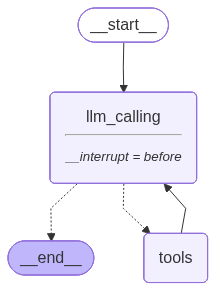

================================ Human Message =================================

What is the product 5 and 3


In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.schema.messages import HumanMessage
from langchain.tools import tool
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import tools_condition, ToolNode
from IPython.display import display, Image
from langgraph.checkpoint.memory import MemorySaver
import os
from dotenv import load_dotenv

load_dotenv()

GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", api_key=GOOGLE_API_KEY)


@tool
def add(a: int, b: int) -> int:
    """Add two numbers and return their sum."""
    try:
        return a + b
    except Exception as e:
        return f"⚠️ Error in addition: {e}"


@tool
def subtract(a: int, b: int) -> int:
    """Subtract the second number from the first and return the result."""
    try:
        return a - b
    except Exception as e:
        return f"⚠️ Error in subtraction: {e}"


@tool
def multiply(a: int, b: int) -> int:
    """Multiply two numbers and return the product."""
    try:
        return a * b
    except Exception as e:
        return f"⚠️ Error in multiplication: {e}"


tools = [add, subtract, multiply]
llm_with_tools = llm.bind_tools(tools)


def llm_calling(state: MessagesState) -> MessagesState:
    return {"messages": llm_with_tools.invoke(state["messages"])}


memory = MemorySaver()
builder = StateGraph(MessagesState)

# Add nodes
builder.add_node("llm_calling", llm_calling)
builder.add_node("tools", ToolNode(tools))

# Edges
builder.add_edge(START, "llm_calling")
builder.add_conditional_edges("llm_calling", tools_condition)
builder.add_edge("tools", "llm_calling")


graph = builder.compile(checkpointer=memory, interrupt_before=["llm_calling"])
display(Image(graph.get_graph().draw_mermaid_png()))

thread = {"configurable": {"thread_id": "chat_1"}}
initial_input = {"messages": [HumanMessage("What is the product 5 and 3")]}

for event in graph.stream(initial_input, config=thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

In [5]:
state = graph.get_state(thread)
state.next

graph.update_state(thread, {"messages": ["No, Actually do for 9 and 9"]})

{'configurable': {'thread_id': 'chat_1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0ba17e-3bbf-607e-8001-1afbca3ccd5d'}}

In [6]:
user_approval = input("Do you want to continue? yes/no: ") or "yes"
if user_approval.lower() == "yes":
    for event in graph.stream(None, config=thread, stream_mode="values"):
        event["messages"][-1].pretty_print()
else:
    print("User cancelled the graph")

================================ Human Message =================================

No, Actually do for 9 and 9
================================== Ai Message ==================================
Tool Calls:
  multiply (ae422df7-9e3e-408d-aef0-ff993b3711cc)
 Call ID: ae422df7-9e3e-408d-aef0-ff993b3711cc
  Args:
    b: 9
    a: 9
================================= Tool Message =================================
Name: multiply

81


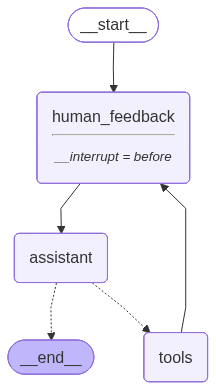

================================ Human Message =================================

What is the product 5 and 3


In [7]:
def human_feedback(state: MessagesState):
    pass

builder2 = StateGraph(MessagesState)
builder2.add_node("assistant", llm_calling)
builder2.add_node("tools", ToolNode(tools))
builder2.add_node("human_feedback", human_feedback)

builder2.add_edge(START, "human_feedback")
builder2.add_edge("human_feedback", "assistant")
builder2.add_conditional_edges("assistant", tools_condition)
builder2.add_edge("tools", "human_feedback")
graph2 = builder2.compile(checkpointer=memory, interrupt_before=["human_feedback"])
thread2 = {"configurable": {"thread_id": "chat_2"}}

display(Image(graph2.get_graph(xray=True).draw_mermaid_png()))

for event in graph.stream(initial_input, config=thread2, stream_mode="values"):
    event["messages"][-1].pretty_print()



In [8]:
user_input = input("How you want to update state: ")
graph2.update_state(thread2, {"messages": user_input}, as_node="human_feedback")

for event in graph2.stream(None, thread2, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

6 and 7
================================== Ai Message ==================================
Tool Calls:
  multiply (4b6ee57b-ad30-430e-8691-cd21d11abd88)
 Call ID: 4b6ee57b-ad30-430e-8691-cd21d11abd88
  Args:
    b: 36
    a: 5
================================= Tool Message =================================
Name: multiply

180


In [9]:
for event in graph2.stream(None, thread2, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

180
